# Fragrantica Data Pipeline
**Project:** Fragheadsunited AI Fragrance Recommendation Engine  
**Dataset:** `perfumes_table.csv`  
**Kolommen:** `rating`, `notes`, `designer`, `reviews`, `description`, `url`, `title`


## 0. Installatie & Imports

In [1]:
# Installeer benodigde packages (eenmalig, verwijder # om te installeren)
# !pip install pandas numpy sentence-transformers scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 120)
print('Imports succesvol geladen.')

Imports succesvol geladen.


---
## 1. Data Inladen

In [ ]:

# AANPASSEN: zet hier het juiste bestandspad
PATH = 'perfumes_table.csv'

df = pd.read_csv(PATH)

print(f'Dataset geladen: {df.shape[0]:,} rijen, {df.shape[1]} kolommen')
print(f'Kolommen: {df.columns.tolist()}')

Dataset geladen: 84,144 rijen, 7 kolommen
Kolommen: ['rating', 'notes', 'designer', 'reviews', 'description', 'url', 'title']


In [ ]:
# Eerste paar rijen bekijken
df.head(5)

,rating,notes,designer,reviews,description,url,title
0,5.00,"['Vanila', 'Madagascar Vanilla', 'Vanilla Absolute']",fiorucci perfumes and colognes,[],Vanilla Scent by Fiorucci is a Amber Vanilla fragrance for women and men. Vanilla Scent was launched in 1961. Top no...,https://www.fragrantica.com/perfume/Fiorucci/Vanilla-Scent-34262.html,Vanilla Scent Fiorucci for women and men
1,4.22,"['Mint', 'Lavender', 'Nutmeg', 'elemi', 'Cypress', 'Sandalwood', 'Saffron', 'Cypriol Oil or Nagarmotha', 'Amber', 'P...",maiora parfum perfumes and colognes,[],Shady by Maiora Parfum is a fragrance for women and men. Shady was launched in 2019. The nose behind this fragrance ...,https://www.fragrantica.com/perfume/Maiora-Parfum/Shady-75400.html,Shady Maiora Parfum for women and men
2,3.81,"['Neroli', 'Vetiver', 'Basil', 'Fig']",guerlain perfumes and colognes,"[""the opening is too sharp that it reminds me of a laundry detergent, but as it settles down, the shaprness goes awa...",Nerolia Vetiver by Guerlain is a Woody Floral Musk fragrance for women and men. This is a new fragrance. Nerolia Vet...,https://www.fragrantica.com/perfume/Guerlain/Nerolia-Vetiver-71757.html,Nerolia Vetiver Guerlain for women and men
3,4.00,"['Orange Blossom', 'Star Anise', 'Pear', 'Rose', 'Mandarin Orange', 'Ylang-Ylang', 'Iris', 'Orchid', 'Plum', 'Ginger...",jean paul gaultier perfumes and colognes,['I must ask. What part of the country did this one show up in? I have not seen it in department stores in San Anton...,Classique Love Actually by Jean Paul Gaultier is a Amber Floral fragrance for women. Classique Love Actually was lau...,https://www.fragrantica.com/perfume/Jean-Paul-Gaultier/Classique-Love-Actually-11356.html,Classique Love Actually Jean Paul Gaultier for women
4,4.22,"['Petitgrain', 'Orange', 'Bergamot', 'Lemon Verbena', 'Lime', 'Grapefruit', 'Lavender', 'African Orange Flower', 'Ja...",santa maria novella perfumes and colognes,"['Beautiful and uplifting. Initially fresh and exuberant, after an hour you are left with ethereal soft green notes....",Zagara (Orange Blossom) by Santa Maria Novella is a Chypre Floral fragrance for women. Zagara (Orange Blossom) was l...,https://www.fragrantica.com/perfume/Santa-Maria-Novella/Zagara-Orange-Blossom-11470.html,Zagara (Orange Blossom) Santa Maria Novella for women


In [5]:
# Datatypes en missing values
print('Datatypes:')
print(df.dtypes)
print()
print('Missing values per kolom:')
print(df.isnull().sum())

Datatypes:
rating         float64
notes           object
designer        object
reviews         object
description     object
url             object
title           object
dtype: object

Missing values per kolom:
rating         81670
notes              0
designer           0
reviews            0
description        8
url                0
title              8
dtype: int64


---
## 2. Data Verkenning (EDA)

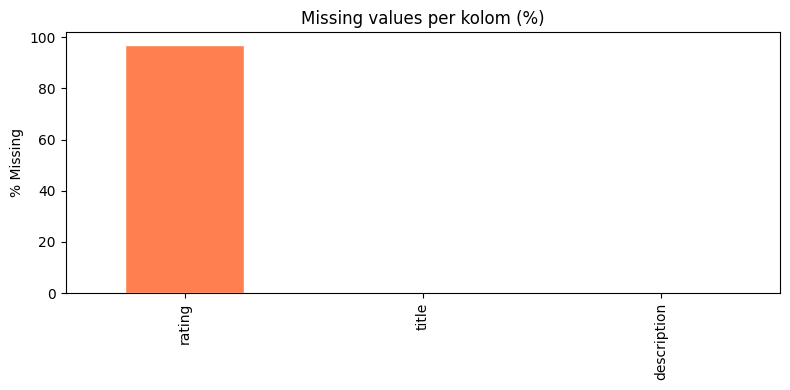

In [6]:
# Missing values visualisatie
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

if len(miss_pct) > 0:
    plt.figure(figsize=(8, 4))
    miss_pct.plot(kind='bar', color='coral', edgecolor='white')
    plt.title('Missing values per kolom (%)')
    plt.ylabel('% Missing')
    plt.tight_layout()
    plt.show()
else:
    print('Geen missing values gevonden.')

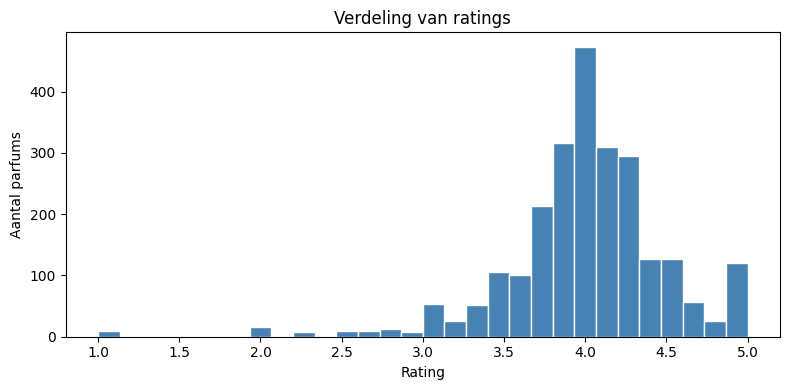

count    2474.000000
mean        3.990061
std         0.512335
min         1.000000
25%         3.790000
50%         4.000000
75%         4.250000
max         5.000000
Name: rating, dtype: float64


In [7]:
# Rating verdeling
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

plt.figure(figsize=(8, 4))
df['rating'].dropna().plot(kind='hist', bins=30, color='steelblue', edgecolor='white')
plt.title('Verdeling van ratings')
plt.xlabel('Rating')
plt.ylabel('Aantal parfums')
plt.tight_layout()
plt.show()

print(df['rating'].describe())

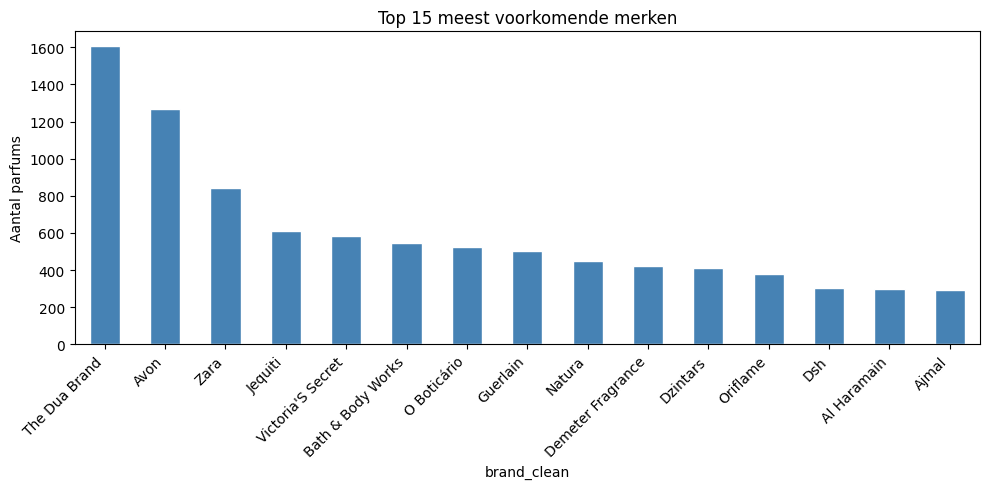

In [8]:
# Top 15 designers (merken)
# 'designer' kolom bevat bijv. 'guerlain perfumes and colognes'
# We extraheren het gedeelte voor 'perfumes' of 'cologne'
df['brand_clean'] = df['designer'].str.split(' perfumes').str[0].str.title()

top_brands = df['brand_clean'].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_brands.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 meest voorkomende merken')
plt.ylabel('Aantal parfums')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

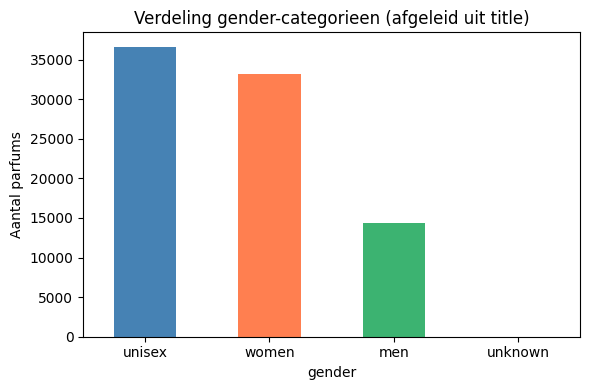

gender
unisex     36616
women      33131
men        14389
unknown        8
Name: count, dtype: int64


In [9]:
# Gender afleiden uit title
def extract_gender(title):
    if not isinstance(title, str):
        return 'unknown'
    t = title.lower()
    if 'for women and men' in t or 'unisex' in t:
        return 'unisex'
    elif 'for women' in t:
        return 'women'
    elif 'for men' in t:
        return 'men'
    return 'unknown'

df['gender'] = df['title'].apply(extract_gender)

gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar', color=['steelblue', 'coral', 'mediumseagreen', 'gray'])
plt.title('Verdeling gender-categorieen (afgeleid uit title)')
plt.ylabel('Aantal parfums')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(gender_counts)

---
## 3. Notes & Reviews Parsen

Beide kolommen zijn opgeslagen als string-representatie van een Python lijst:  
`"['Vanilla', 'Lavender', 'Sandalwood']"` wordt omgezet naar een echte lijst.

In [10]:
def parse_list_column(val):
    """Zet string-lijst om naar echte Python list."""
    if pd.isna(val) or str(val).strip() in ('[]', ''):
        return []
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else [str(result)]
    except:
        return [str(val)]


def clean_text(text):
    """Basis tekstopschoning."""
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = text.replace("\\'s", "'s").replace('\\"', '"')
    return text


# Parsen
df['notes_list']   = df['notes'].apply(parse_list_column)
df['reviews_list'] = df['reviews'].apply(parse_list_column)

# Tekstvelden
df['notes_text']   = df['notes_list'].apply(lambda lst: ', '.join(lst))
df['reviews_text'] = df['reviews_list'].apply(
    lambda lst: ' '.join([clean_text(r) for r in lst if isinstance(r, str) and len(r) > 20])
)
df['review_count'] = df['reviews_list'].apply(len)

print(f'Parfums met reviews:    {(df["review_count"] > 0).sum():,}')
print(f'Parfums zonder reviews: {(df["review_count"] == 0).sum():,}')
print(f'Gemiddeld per parfum:   {df["review_count"].mean():.1f}')
print()
print('Voorbeeld notes_text:')
print(df['notes_text'].iloc[2])
print()
print('Voorbeeld reviews_text (eerste 300 tekens):')
print(df[df['review_count'] > 0]['reviews_text'].iloc[0][:300])

Parfums met reviews:    54,033
Parfums zonder reviews: 30,111
Gemiddeld per parfum:   15.9

Voorbeeld notes_text:
Neroli, Vetiver, Basil, Fig

Voorbeeld reviews_text (eerste 300 tekens):
the opening is too sharp that it reminds me of a laundry detergent, but as it settles down, the shaprness goes away and i get to sense the fresh, orangey, soft, floral qualities of the neroli, which is the main event of this scent. It also has a green, herbaceous tone in it, which is probably courte


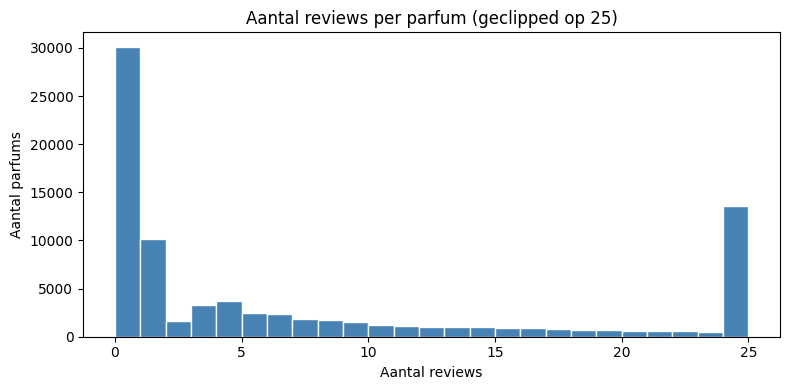

In [11]:
# Review count verdeling
plt.figure(figsize=(8, 4))
df['review_count'].clip(upper=25).plot(kind='hist', bins=25, color='steelblue', edgecolor='white')
plt.title('Aantal reviews per parfum (geclipped op 25)')
plt.xlabel('Aantal reviews')
plt.ylabel('Aantal parfums')
plt.tight_layout()
plt.show()

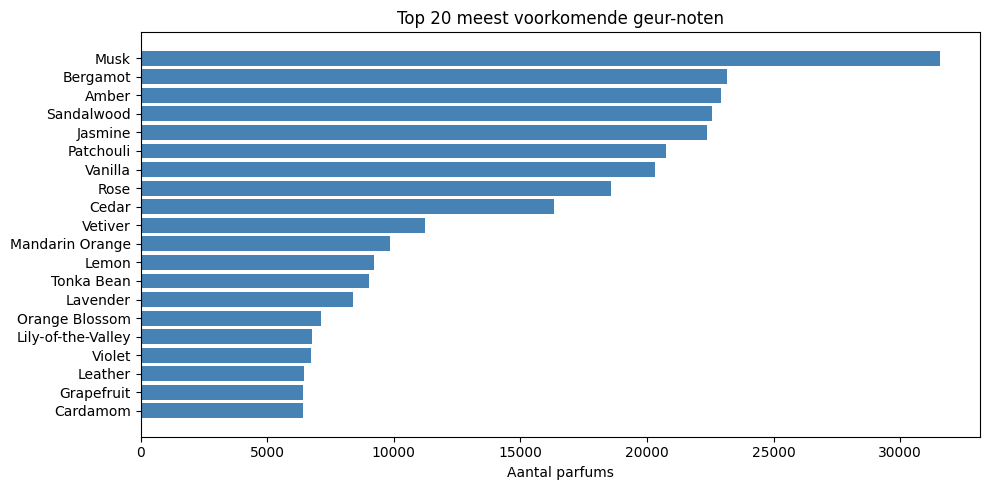

In [12]:
# Meest voorkomende geur-noten
all_notes = [note for notes in df['notes_list'] for note in notes]
top_notes = Counter(all_notes).most_common(20)
notes_df = pd.DataFrame(top_notes, columns=['Note', 'Count'])

plt.figure(figsize=(10, 5))
plt.barh(notes_df['Note'][::-1], notes_df['Count'][::-1], color='steelblue')
plt.title('Top 20 meest voorkomende geur-noten')
plt.xlabel('Aantal parfums')
plt.tight_layout()
plt.show()

---
## 4. Embedding Tekst Opbouwen

We combineren alle velden tot een rijke `embedding_text` per parfum voor gebruik in NLP/RAG.

In [13]:
def build_embedding_text(row):
    """Bouwt een rijke tekst op voor embeddings per parfum."""
    parts = []

    if pd.notna(row.get('title')):
        parts.append(f"Perfume: {row['title']}")
    if pd.notna(row.get('brand_clean')):
        parts.append(f"Brand: {row['brand_clean']}")
    if pd.notna(row.get('gender')):
        parts.append(f"Gender: {row['gender']}")
    if pd.notna(row.get('rating')):
        parts.append(f"Rating: {row['rating']}")
    if row.get('notes_text', ''):
        parts.append(f"Notes: {row['notes_text']}")

    desc = clean_text(str(row.get('description', '')))
    if desc and desc != 'nan':
        parts.append(f"Description: {desc}")

    rev = str(row.get('reviews_text', '')).strip()
    if rev and rev != 'nan':
        parts.append(f"Reviews: {rev[:500]}")

    return ' | '.join(parts)


df['embedding_text'] = df.apply(build_embedding_text, axis=1)
df['text_length']    = df['embedding_text'].str.len()

print('Voorbeeld embedding_text:')
print('-' * 80)
print(df['embedding_text'].iloc[2])

Voorbeeld embedding_text:
--------------------------------------------------------------------------------
Perfume: Nerolia Vetiver Guerlain for women and men | Brand: Guerlain | Gender: unisex | Rating: 3.81 | Notes: Neroli, Vetiver, Basil, Fig | Description: Nerolia Vetiver by Guerlain is a Woody Floral Musk fragrance for women and men. This is a new fragrance. Nerolia Vetiver was launched in 2022. Nerolia Vetiver was created by Delphine Jelk and Thierry Wasser. | Reviews: the opening is too sharp that it reminds me of a laundry detergent, but as it settles down, the shaprness goes away and i get to sense the fresh, orangey, soft, floral qualities of the neroli, which is the main event of this scent. It also has a green, herbaceous tone in it, which is probably courtesy of the basil. The fig note is also there underneath giving it a bit of creaminess, which made me realize that neroli and fig could make a really interesting and pleasant combination. I unfortunatel


count    84144.0
mean       721.0
std        292.0
min         44.0
25%        452.0
50%        783.0
75%        971.0
max       2168.0
Name: text_length, dtype: float64


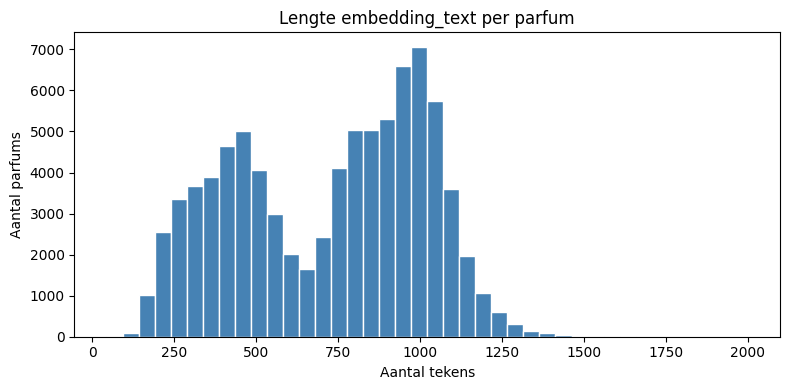

In [14]:
# Tekst-lengte statistieken
print(df['text_length'].describe().round(0))

plt.figure(figsize=(8, 4))
df['text_length'].clip(upper=2000).plot(kind='hist', bins=40, color='steelblue', edgecolor='white')
plt.title('Lengte embedding_text per parfum')
plt.xlabel('Aantal tekens')
plt.ylabel('Aantal parfums')
plt.tight_layout()
plt.show()

---
## 5. Dataset Opslaan

In [15]:
df.to_csv('fragrantica_final.csv', index=False)
print(f'Opgeslagen: fragrantica_final.csv ({len(df):,} rijen)')
print(f'Kolommen: {df.columns.tolist()}')

Opgeslagen: fragrantica_final.csv (84,144 rijen)
Kolommen: ['rating', 'notes', 'designer', 'reviews', 'description', 'url', 'title', 'brand_clean', 'gender', 'notes_list', 'reviews_list', 'notes_text', 'reviews_text', 'review_count', 'embedding_text', 'text_length']


---
## 6. Embeddings Genereren (Sentence Transformers)

> Voor de volledige dataset: verwijder `.head(500)` hieronder.

In [16]:
!pip install sentence-transformers

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 817.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/512.4 kB ? eta -:--:--
   ------------------------------ --------- 389.1/512.4 kB 8.1 MB/s eta 0:00:01
   ---------------------------------------  512.0/512.4 kB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 512.4/512.4 kB 5.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.2/8.1 MB 5.8 MB/s eta 0:00:02
   -- ------------------------------------- 0.4/8.1 MB 5.2 MB/s eta 0:00:02
   --- ------------------------------------ 0.7/8.1 MB 5.7 MB/s eta 0:00:02
   ---- ----------------------------------- 0.8/8.1 MB 5.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.1 MB 6.1 MB/s eta 0:00:02
   -----


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Laptop\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model geladen.')

# Subset voor testen (verwijder .head(500) voor volledige dataset)
df_sample = df.dropna(subset=['embedding_text']).head(500).reset_index(drop=True)

print(f'Embeddings genereren voor {len(df_sample):,} parfums...')
embeddings = model.encode(
    df_sample['embedding_text'].tolist(),
    batch_size=64,
    show_progress_bar=True
)
print(f'Embedding shape: {embeddings.shape}')

Model geladen.
Embeddings genereren voor 500 parfums...


Batches: 100%|██████████| 8/8 [00:10<00:00,  1.37s/it]

Embedding shape: (500, 384)


In [18]:
# Opslaan voor hergebruik
np.save('fragrantica_embeddings.npy', embeddings)
df_sample[['title', 'brand_clean', 'rating', 'gender', 'notes_text']].to_csv(
    'fragrantica_index.csv', index=False
)
print('Opgeslagen: fragrantica_embeddings.npy + fragrantica_index.csv')

Opgeslagen: fragrantica_embeddings.npy + fragrantica_index.csv


---
## 7. Aanbevelingsfunctie (Proof of Concept)

In [19]:
def recommend_perfumes(query: str, top_k: int = 5, gender_filter: str = None):
    """
    Geef parfum-aanbevelingen op basis van een vrije tekstquery.

    Parameters:
        query         : Beschrijving van gewenst parfum (bijv. 'fresh citrus summer')
        top_k         : Aantal aanbevelingen
        gender_filter : Optioneel filteren op 'men', 'women' of 'unisex'
    """
    query_embedding = model.encode([query])
    similarities    = cosine_similarity(query_embedding, embeddings)[0]

    results = df_sample[['title', 'brand_clean', 'rating', 'gender', 'notes_text']].copy()
    results['similarity'] = similarities.round(3)

    if gender_filter:
        results = results[results['gender'] == gender_filter]

    results = results.sort_values('similarity', ascending=False).head(top_k)
    results = results.reset_index(drop=True)
    results.index += 1
    return results


# Test 1
print('=== "fresh citrus summer beach" ===')
recommend_perfumes('fresh citrus summer beach', top_k=5)

=== "fresh citrus summer beach" ===


,title,brand_clean,rating,gender,notes_text,similarity
1,Baby Boy Franck Olivier for men,Franck Olivier,2.33,men,"Mandarin Orange, Freesia, Orange Blossom, Pear, Peony, Sandalwood, Heliotrope, Raspberry",0.439
2,Maui Mango Surf Bath & Body Works for women,Bath & Body Works,4.00,women,"Mango, Mai Tai Cocktail, Sea Notes, Musk, Sandalwood",0.438
3,City Of Stars Louis Vuitton for women and men,Louis Vuitton,4.09,unisex,"Lime, Blood Orange, Blood Mandarin, Lemon, Bergamot, Tiare Flower, Powdery Notes, Musk, Sandalwood",0.435
4,Lovely Sweet Sixteen Jeanne Arthes for women,Jeanne Arthes,3.89,women,"Black Currant, Lemon, Mandarin Orange, Green Leaves, Peach, Apple, Freesia, Rose, Lily-of-the-Valley, Sandalwood, Wh...",0.430
5,Divins Alcools Lucky Bay Sabe Masson for women,Sabe Masson,4.60,women,"Mandarin Orange, Neroli, Mint, Cinnamon, Lemon, Cardamom, Orange Blossom, Petitgrain, Rose, Cloves, Sandalwood, Patc...",0.418


In [20]:
# Test 2
print('=== "dark woody oud oriental" ===')
recommend_perfumes('dark woody oud oriental', top_k=5)

=== "dark woody oud oriental" ===


,title,brand_clean,rating,gender,notes_text,similarity
1,Ghassan Hamidi Oud & Perfumes for women and men,Hamidi Oud &,4.00,unisex,"Woody Notes, Musk, Agarwood (Oud), Vanilla, Saffron",0.480
2,WHITE OUD AAP PERFUMES for women and men,Aap,NaN,unisex,"Raspberry, Saffron, White Oud, Jasmine, Olibanum, White Oud, Leather, Suede, Amber",0.468
3,Oudh Deep Spray Henry Jacques for men,Henry Jacques,4.25,men,Agarwood (Oud),0.449
4,Borneo Zen Ensar Oud for women and men,Ensar Oud,4.72,unisex,"Jasmine, Turkish Rose, Honeysuckle, Natural Musk, Agarwood (Oud), Sandalwood, Violet, Blackberry, Orange Peel",0.439
5,Oud Sultan Maïssa Parfums for women and men,Maïssa Parfums,3.69,unisex,"Bulgarian Rose, Patchouli, Agarwood (Oud), Olibanum, Cedar, Saffron, Sandalwood",0.431


In [ ]:
# Test 3 met gender filter
print('=== "sweet floral rose" (alleen women) ===')
recommend_perfumes('sweet floral rose jasmine', top_k=5, gender_filter='women')

=== "sweet floral rose" (alleen women) ===


,title,brand_clean,rating,gender,notes_text,similarity
1,Dazzling Grace Oriflame for women,Oriflame,3.35,women,"Citruses, Mandarin Orange, White Flowers, Magnolia, Patchouli, Exotic Woods",0.602
2,Floralique Avon for women,Avon,4.00,women,"Pineapple, Gardenia, Violet, Jasmine, Lily-of-the-Valley, Rose, Vanilla, Sandalwood, Musk",0.583
3,Lovely Sweet Sixteen Jeanne Arthes for women,Jeanne Arthes,3.89,women,"Black Currant, Lemon, Mandarin Orange, Green Leaves, Peach, Apple, Freesia, Rose, Lily-of-the-Valley, Sandalwood, Wh...",0.582
4,Pleasures Flower Estée Lauder for women,Estée Lauder,3.77,women,"Orange Blossom, Cassis, Bergamot, Lemon, Jasmine, Lily-of-the-Valley, Rose, Peony, Coconut Nectar, Ambroxan, Incense...",0.581
5,Pirouette Angel Schlesser for women,Angel Schlesser,3.54,women,"Rose, Black Currant, Plum, Bergamot, Cacao Pod, Iris, Orchid, Freesia, Lily-of-the-Valley, Jasmine, White Musk, Vani...",0.572


In [22]:
# Vrije query — zelf invullen
mijn_query = "warm spicy vanilla amber"  # <-- aanpassen
print(f'=== "{mijn_query}" ===')
recommend_perfumes(mijn_query, top_k=10)

=== "warm spicy vanilla amber" ===


,title,brand_clean,rating,gender,notes_text,similarity
1,Vanille Divine des Tropiques La Maison de la Vanille for women,La Maison De La Vanille,3.97,women,"Amber, Jasmine, Tuberose, Hyacinth, Vanilla, Heliotrope, Gardenia, Jasmine",0.566
2,"Black Pepper & Amber, Neroli Zielinski & Rozen for women and men",Zielinski & Rozen,4.19,unisex,"Black Pepper, Amber, Neroli",0.553
3,I Love Dreaming Dzintars for women,Dzintars,4.07,women,"Bitter Orange, Tangerine, Stephanotis, Caramel, Lemon Verbena, Orchid, Rose, Patchouli, Vanilla, Mahogany, Saffron",0.537
4,Ruby Red The House of Oud for women and men,The House Of Oud,4.12,unisex,"Ginger, Tangerine, Tuberose, Ylang-Ylang, Ginger flower, Candied Ginger, Vanilla, Woody Notes, Musk",0.518
5,Radiance Verset Parfums for women,Verset Parfums,4.29,women,"Jasmine, Orange Blossom, White Amber",0.516
6,L'Olfactive 129 Crazylibellule and the Poppies for women,Crazylibellule And The Poppies,4.00,women,"Bergamot, Orange, Mandarin Orange, Pepper, Honey, Ylang-Ylang, elemi, Vanilla, Amber, Patchouli",0.505
7,Oak in Bourbon Scents of Wood for women and men,Scents Of Wood,3.41,unisex,"Oak, Madagascar Pepper, Star Anise, Lavender, Geranium, Guaiac Wood, Ginger, Cypriol Oil or Nagarmotha, Haitian Vetiver",0.497
8,Rendezvous Glasshouse for women,Glasshouse,3.59,women,"Citruses, Orchid, Lily, Sugar Cane, Iris, Rose, Heliotrope, Musk, Patchouli, Amber, White Cedar Extract, Vanilla",0.495
9,Shisha Lounge Ricardo Ramos Perfumes de Autor for women and men,Ricardo Ramos,3.08,unisex,"Anise, Red Fruits, Hazelnut, Neroli, Tobacco, Oakmoss, Labdanum, Patchouli, Amber, Madagascar Vanilla, Tonka Bean, Musk",0.491
10,Vanille Leather BDK Parfums for women and men,Bdk Parfums,3.97,unisex,"Violet, Pink Pepper, Jasmine, Tuberose, Orange Blossom, Vanilla, Leather, Orris, Benzoin, Oak, Patchouli",0.486
